In [3]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import scanpy as sc
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

import os, re
import sklearn
import time
import string
import logomaker
import glob
from matplotlib.ticker import FormatStrFormatter
from sklearn.metrics import adjusted_mutual_info_score as AMI
from matplotlib.patches import Patch
from pathlib import Path
from scipy import io
from helps import *
pd.set_option("display.precision", 12)
palette={alg : colors_to_use_pastel[i] for i,alg in enumerate(["ShareTopic","Mowgli","bionSBM"])}

# Fig 3

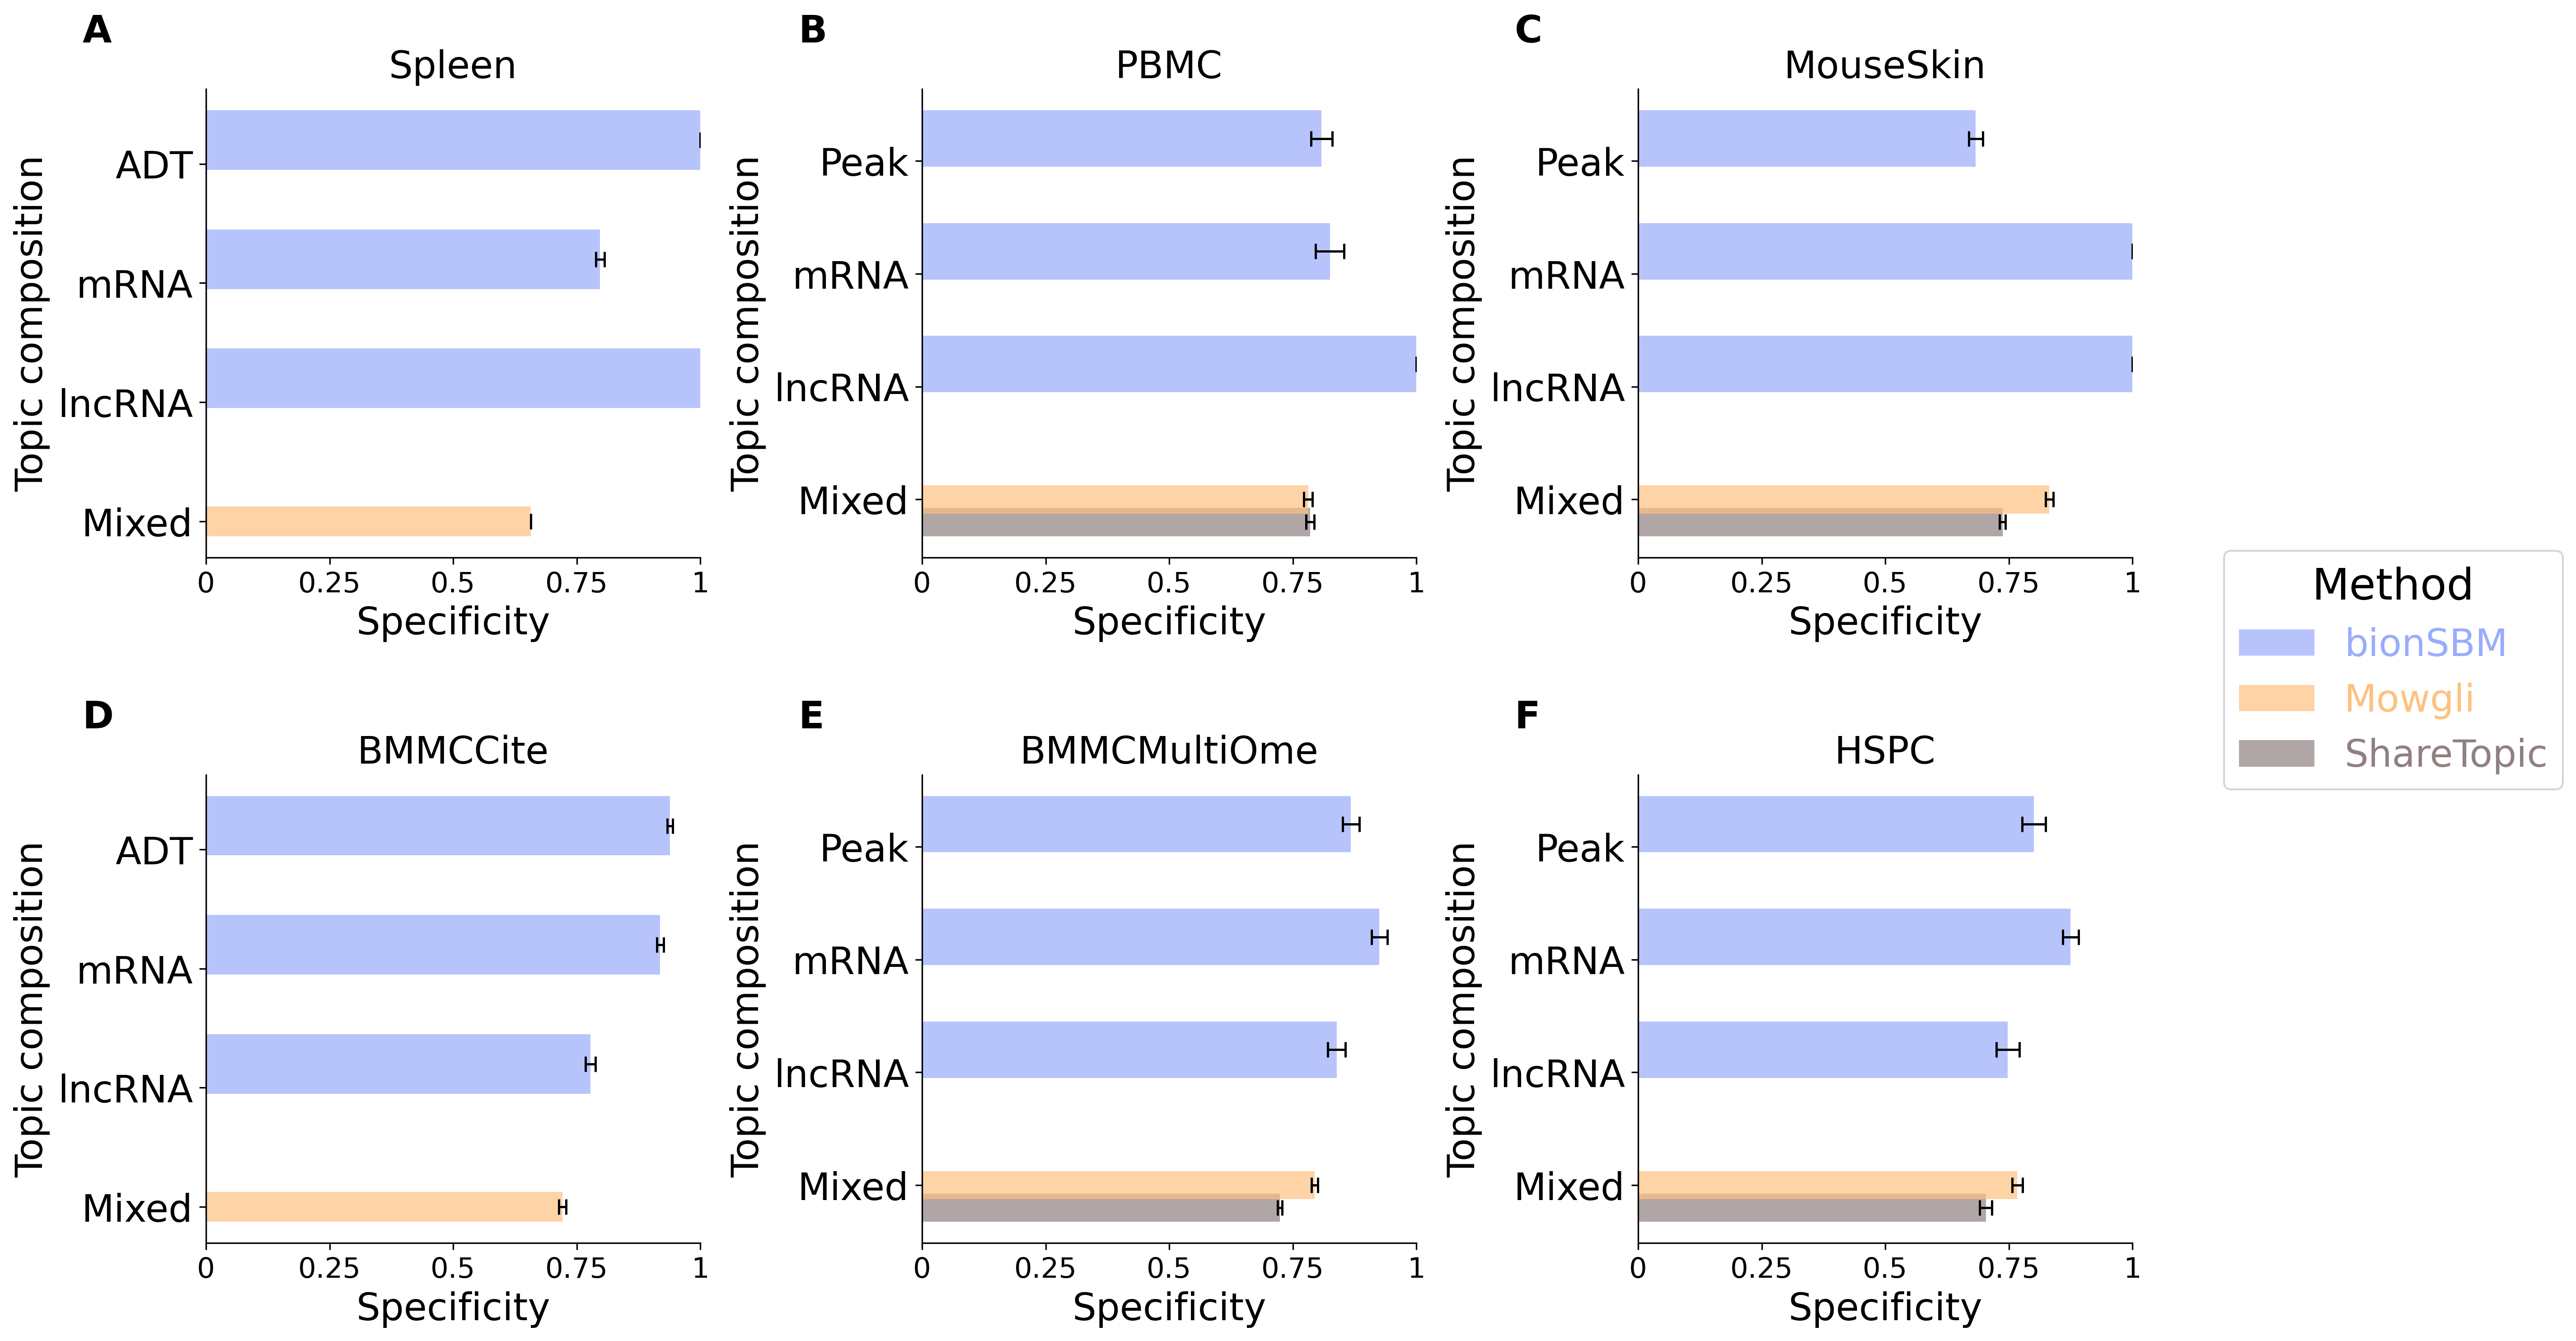

In [25]:
params = {'axes.labelsize': 20,
         'axes.titlesize': 20,
         'xtick.labelsize' : 15,
         'ytick.labelsize': 15,
         "lines.linewidth" : 4,
         "figure.dpi" : 300,
         "figure.figsize": [16, 10]}
plt.rcParams.update(params)
fig, axs = plt.subplots(2,3)
axs=axs.flatten()


for l, dataset in enumerate(["Spleen","PBMC","MouseSkin", "BMMCCite", "BMMCMultiOme","HSPC"]):
    df = create_results_topics(dataset,exps=["bionSBM_Peak_mRNA_lncRNA","Mowgli_Peak_mRNA_lncRNA","ShareTopic_Peak_mRNA",
            "ShareTopic_Peak_lncRNA","bionSBM_ADT_mRNA_lncRNA","Mowgli_ADT_mRNA_lncRNA"]).replace({"_" : "+"}, regex=True)
    
    df["Specificty"] = df["DifferentTopics"] / df["NumberOfTopics"]

    if dataset in ["BMMCCite", "Spleen"]:
        order = ["ADT", "mRNA", "lncRNA", "Mixed"][::-1]
    else:
        order = ["Peak", "mRNA", "lncRNA", "Mixed"][::-1]

    for i, meth in enumerate(palette.keys()):
        d = df[df["Algorithm"] == meth]

        means = d.groupby("FS")["Specificty"].mean()
        sems  = 3*d.groupby("FS")["Specificty"].sem()

        fs_present = [o for o in order if o in means.index]
        y_positions = np.array([order.index(o) for o in fs_present], dtype=float)
        offset = (i - (len(palette) - 1) / 2) * 0.2
        y_positions += offset

        # Horizontal bar
        height = 0.5 if meth == "bionSBM" else 0.25
        axs[l].barh(y_positions, means[fs_present], height=height,color=palette[meth], alpha=0.7, label=meth)

        # Error bars aligned with the bar
        axs[l].errorbar(x=means[fs_present],y=y_positions,xerr=sems[fs_present],fmt='none',
            ecolor='black',elinewidth=1.2,capsize=4,capthick=1.2)
    axs[l].spines['top'].set_visible(False)
    axs[l].spines['right'].set_visible(False)  
    axs[l].spines['bottom'].set_visible(True)
    axs[l].spines['left'].set_visible(True)  
    axs[l].set_title(dataset)
    axs[l].set_xlim([0, 1])
    axs[l].set_yticks(range(len(order)), range(len(order)), fontsize=20)
    axs[l].set_yticklabels(order)
    axs[l].set_xticks([0,0.25, 0.5, 0.75, 1],["0","0.25", "0.5", "0.75", "1"])
    axs[l].set_xlabel("Specificity")
    axs[l].set_ylabel("Topic composition")
    axs[l].annotate(string.ascii_uppercase[l],xy=(-0.25, 1.1),xycoords='axes fraction',fontsize=20,fontweight="bold",ha='left')

handles, labels = axs[2].get_legend_handles_labels()
desired_order = ["bionSBM", "Mowgli", "ShareTopic"]
order_idx = [labels.index(m) for m in desired_order]
handles = [handles[i] for i in order_idx]
labels = [labels[i] for i in order_idx]
fig.legend(handles, labels, loc="center left", bbox_to_anchor=(1.02, 0.5), ncol=1, title="Method", fontsize=20, title_fontsize=23, labelcolor=[palette[key] for key in labels])
fig.tight_layout(h_pad=3)
plt.savefig(f"Figures/bionSBM_Fig3.png", format="png", dpi=300, bbox_inches='tight')
plt.show()

# Fig 4

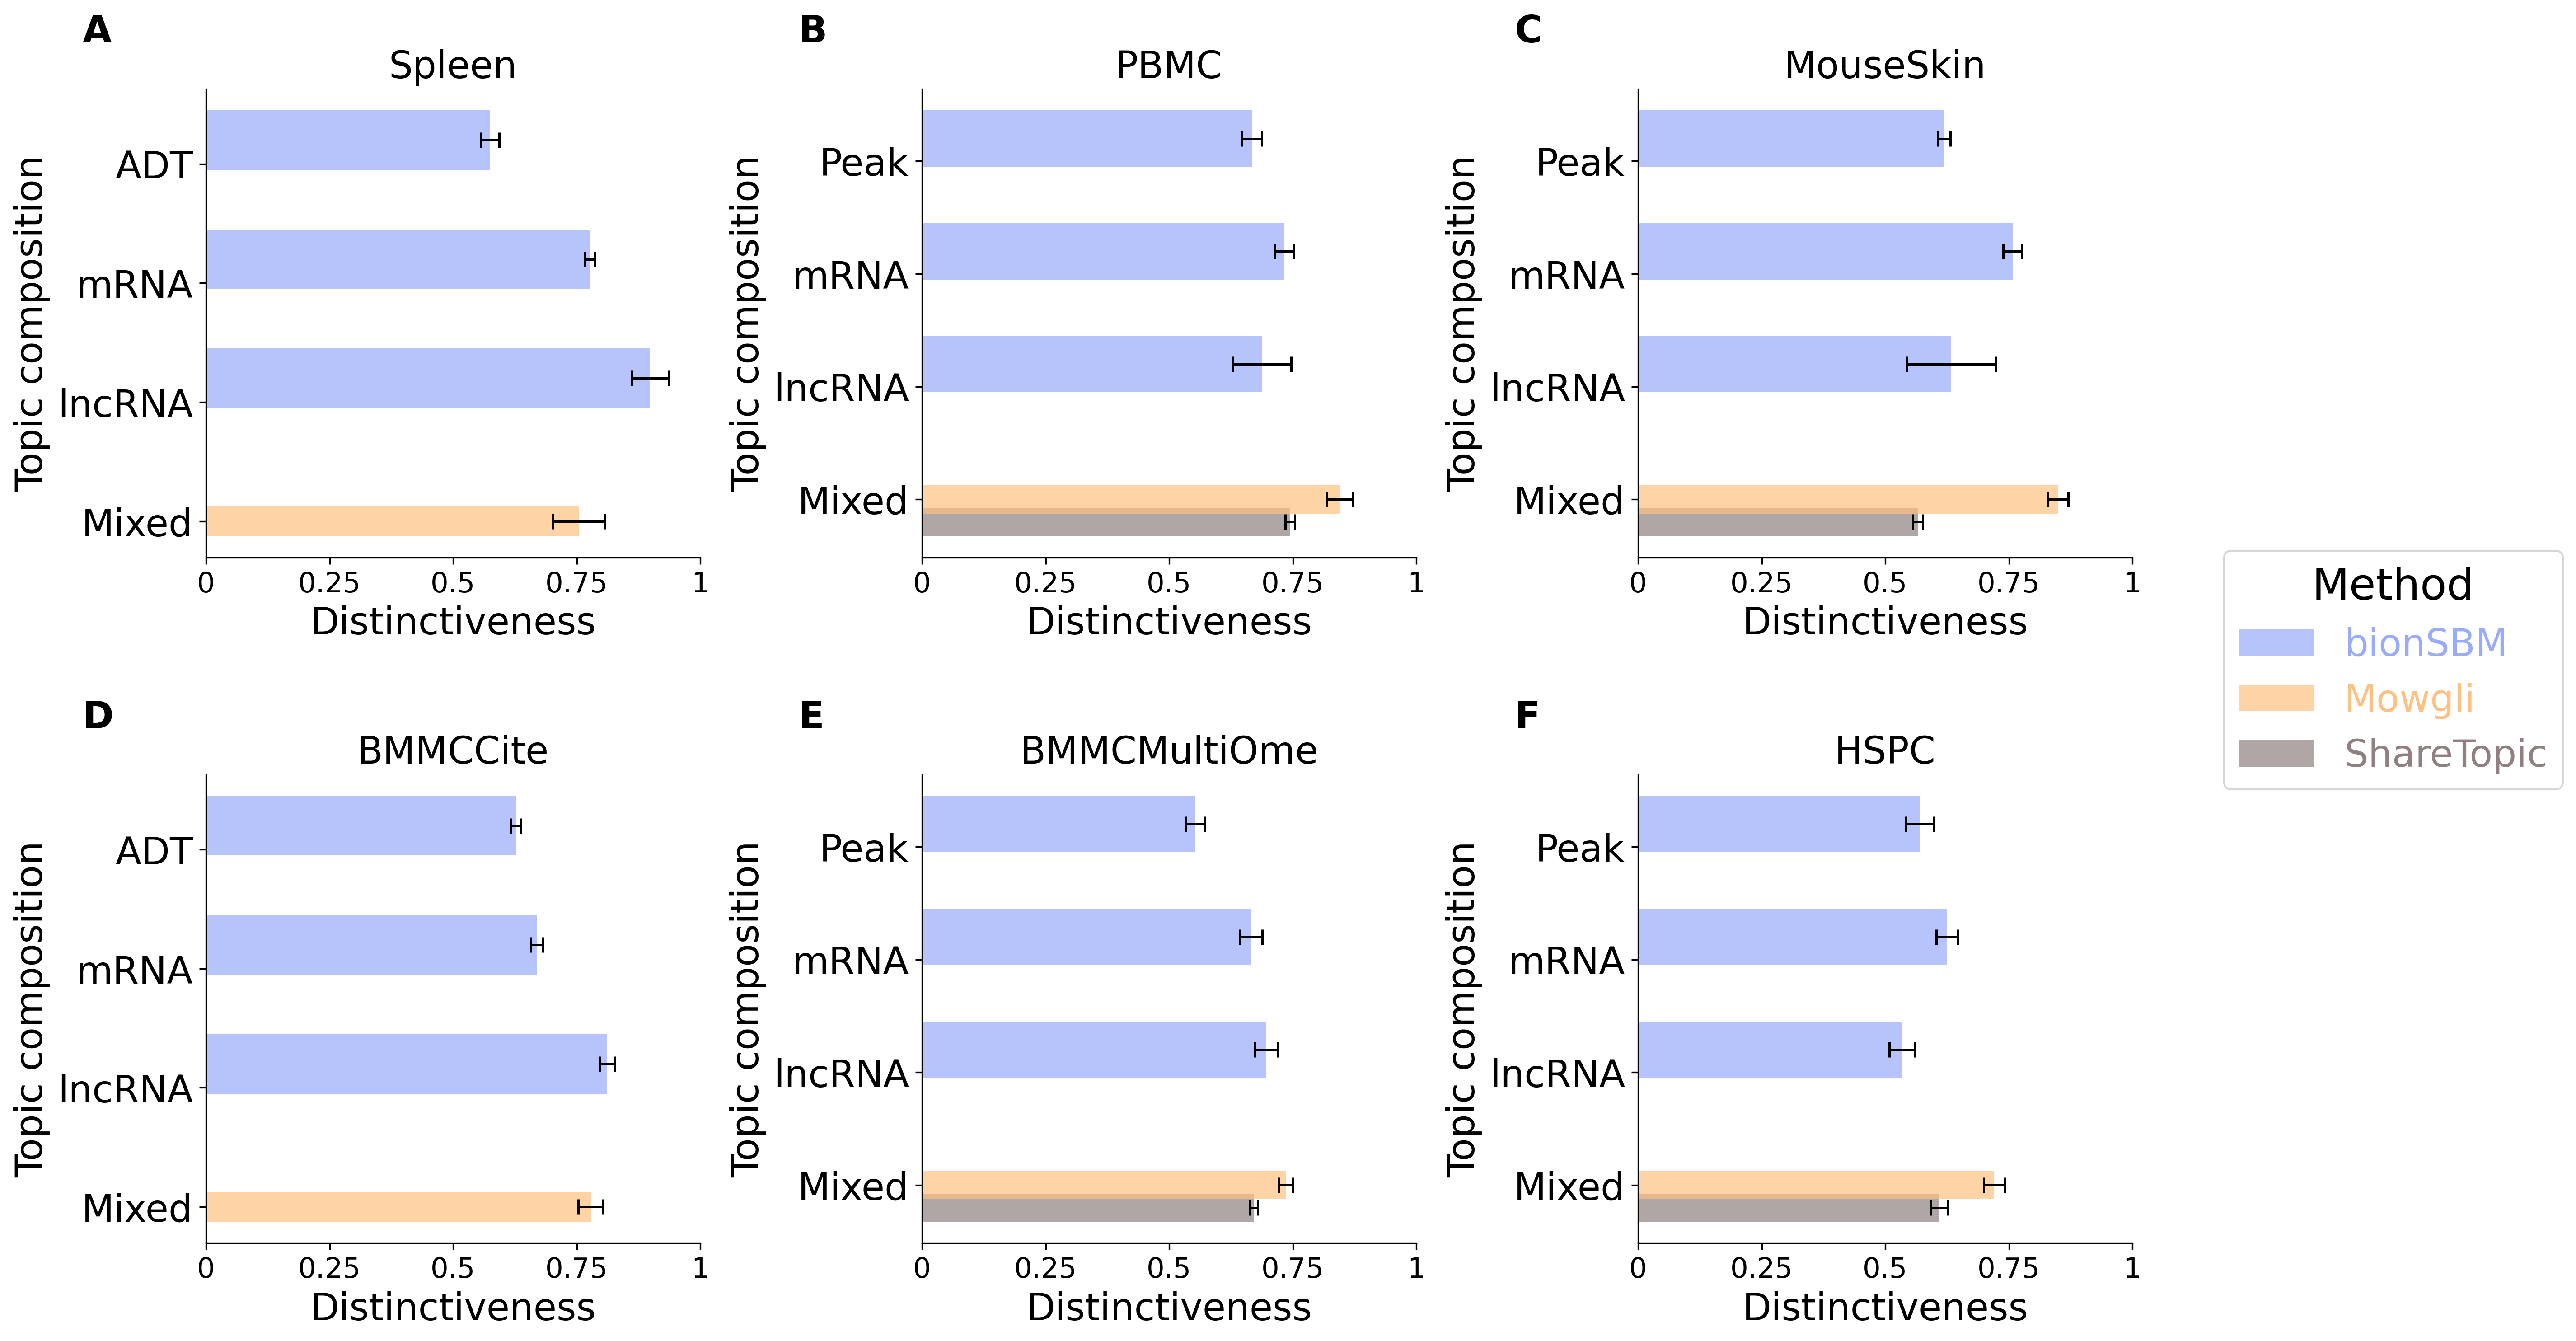

In [26]:
params = {'axes.labelsize': 20,
         'axes.titlesize': 20,
         'xtick.labelsize' : 15,
         'ytick.labelsize': 15,
         "lines.linewidth" : 4,
         "figure.dpi" : 300,
         "figure.figsize": [16, 10]}
plt.rcParams.update(params)
fig, axs = plt.subplots(2,3)
axs=axs.flatten()

for l, dataset in enumerate(["Spleen","PBMC","MouseSkin", "BMMCCite", "BMMCMultiOme","HSPC"]):
    df = create_results_topics(
        dataset,
        exps=["bionSBM_Peak_mRNA_lncRNA","Mowgli_Peak_mRNA_lncRNA","ShareTopic_Peak_mRNA",
              "ShareTopic_Peak_lncRNA","bionSBM_ADT_mRNA_lncRNA","Mowgli_ADT_mRNA_lncRNA"]).replace({"_" : "+"}, regex=True)

    if dataset in ["BMMCCite", "Spleen"]:
        order = ["ADT", "mRNA", "lncRNA", "Mixed"][::-1]
    else:
        order = ["Peak", "mRNA", "lncRNA", "Mixed"][::-1]

    for i, meth in enumerate(palette.keys()):
        d = df[df["Algorithm"] == meth]

        means = d.groupby("FS")["Topics_distinctiveness"].mean()
        sems  = 3*d.groupby("FS")["Topics_distinctiveness"].sem()

        fs_present = [o for o in order if o in means.index]
        y_positions = np.array([order.index(o) for o in fs_present], dtype=float)
        offset = (i - (len(palette) - 1) / 2) * 0.2
        y_positions += offset

        # Horizontal bar
        height = 0.5 if meth == "bionSBM" else 0.25
        axs[l].barh(y_positions,means[fs_present],height=height,color=palette[meth],alpha=0.7,label=meth)

        # Error bars aligned with the bar
        axs[l].errorbar(x=means[fs_present],y=y_positions,xerr=sems[fs_present],fmt='none',ecolor='black',elinewidth=1.2,capsize=4,capthick=1.2)
        
    axs[l].spines['top'].set_visible(False)
    axs[l].spines['right'].set_visible(False)  
    axs[l].spines['bottom'].set_visible(True)
    axs[l].spines['left'].set_visible(True)  
    axs[l].set_title(dataset)
    axs[l].set_xlim([0, 1])
    axs[l].set_yticks(range(len(order)), range(len(order)), fontsize=20)
    axs[l].set_yticklabels(order)
    axs[l].set_xticks([0,0.25, 0.5, 0.75, 1],["0","0.25", "0.5", "0.75", "1"])
    axs[l].set_xlabel("Distinctiveness")
    axs[l].set_ylabel("Topic composition")
    axs[l].annotate(string.ascii_uppercase[l],xy=(-0.25, 1.1),xycoords='axes fraction',fontsize=20,fontweight="bold",ha='left')

handles, labels = axs[2].get_legend_handles_labels()
desired_order = ["bionSBM", "Mowgli", "ShareTopic"]
order_idx = [labels.index(m) for m in desired_order]
handles = [handles[i] for i in order_idx]
labels = [labels[i] for i in order_idx]
fig.legend(handles, labels, loc="center left", bbox_to_anchor=(1.02, 0.5), ncol=1, title="Method", fontsize=20, title_fontsize=23, labelcolor=[palette[key] for key in labels])
fig.tight_layout(h_pad=3)
plt.savefig(f"Figures/bionSBM_Fig4.png", format="png", dpi=300, bbox_inches='tight')
plt.show()

# Fig 5

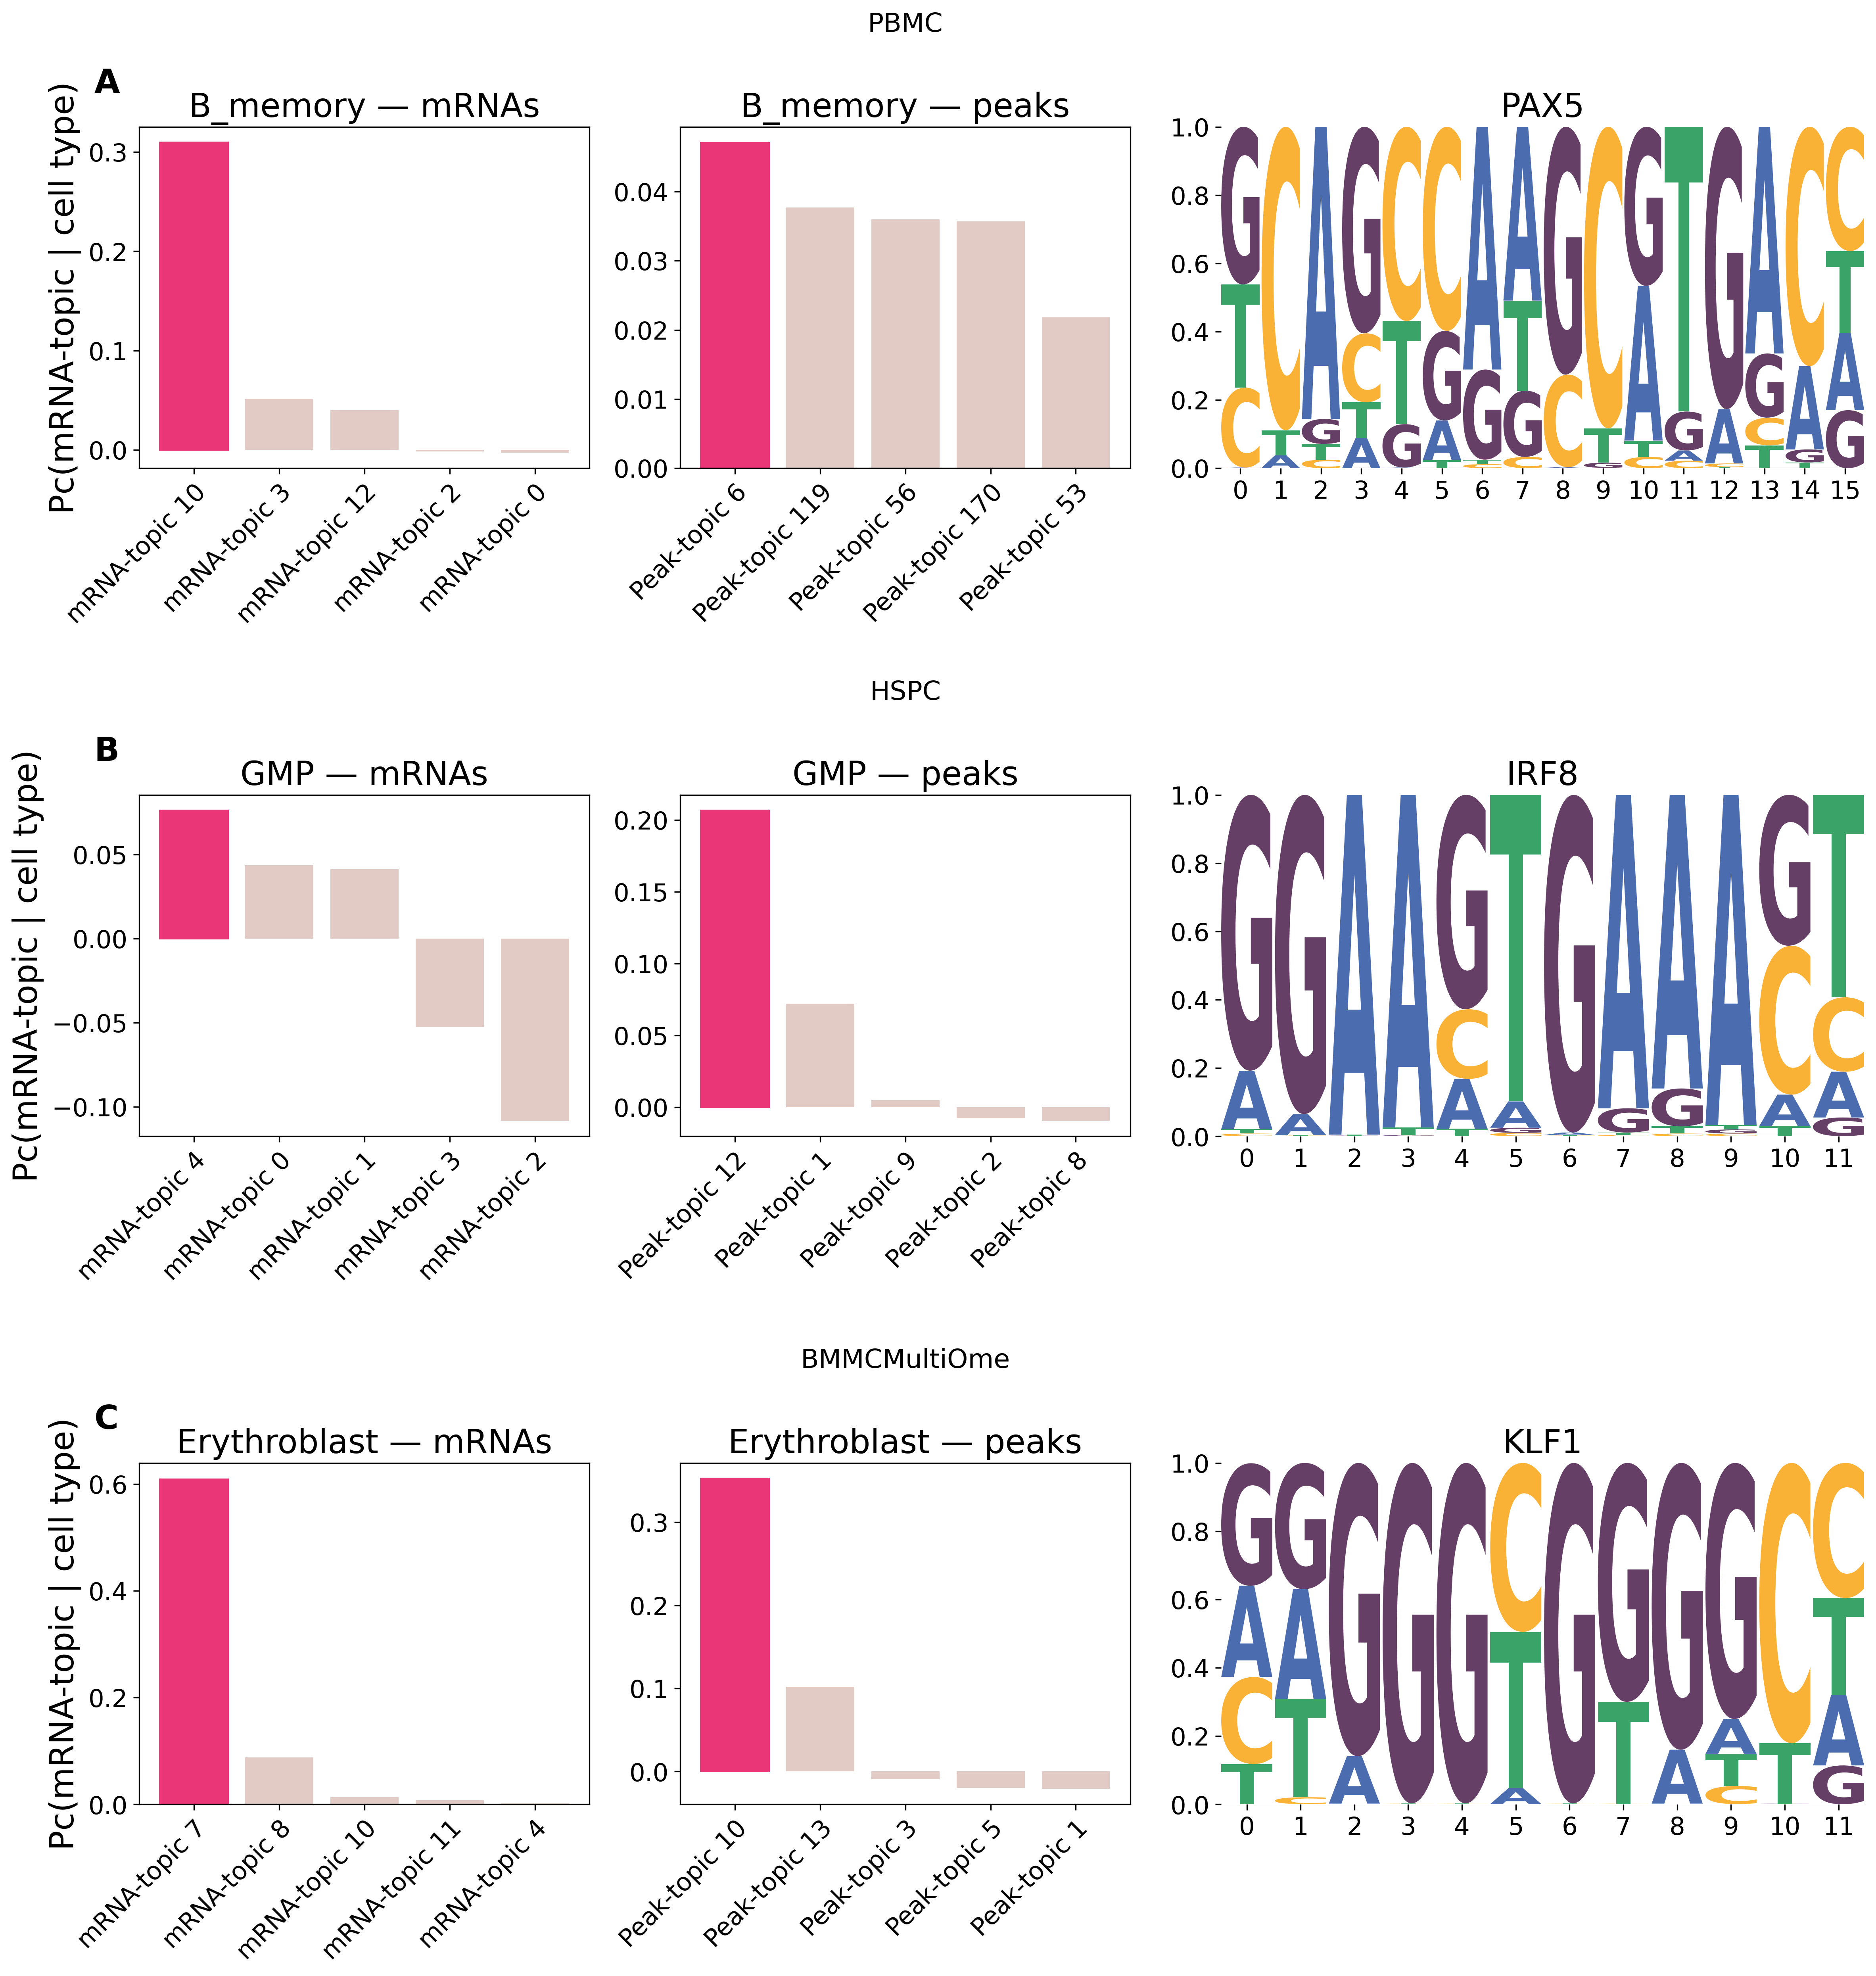

In [24]:
validation_df = pd.DataFrame([
    ["PBMC", "B_memory", "Topic 10", "Topic 6", "PAX5", 22, 0, "Top on both", 156, "Datasets/PBMC/bionSBM/Motifs/Peak_mRNA_lncRNA/Run22/Topic_6/knownResults.html"],
    ["HSPC", "GMP", "Topic 4", "Topic 12", "IRF8", 5, 2, "-", 44, 'Datasets/HSPC/bionSBM/Motifs/Peak_mRNA_lncRNA/Run5/Topic_12/knownResults.html'],
    ["BMMCMultiOme", "Erythroblast", "Topic 7", "Topic 10", "KLF1",19, 3, "Top in all 3", 10, 'Datasets/BMMCMultiOme/bionSBM/Motifs/Peak_mRNA_lncRNA/Run19/Topic_10/knownResults.html']],                              
    columns=["Dataset", "CellType", "mRNA-Topic", "Peak-topic", "Gene in mRNA-Topic", "Run", "Level", "Note", "Motif_Number", "Motif_HTML"])

# --------------------------------------------------
# Colors (already defined in your environment)
# --------------------------------------------------
dna_colors = {
    "A": colors_to_use[19],
    "C": colors_to_use[14],
    "G": colors_to_use[2],
    "T": colors_to_use[5]
}

BASE_COLOR = colors_to_use[11]
HIGHLIGHT_COLOR = colors_to_use[16]

top_n = 5
# ---------------------------------------------
# Create single 3x3 figure
# ---------------------------------------------
params = {'axes.labelsize': 20,
         'axes.titlesize': 20,
         'xtick.labelsize' : 15,
         'ytick.labelsize': 15,
         "lines.linewidth" : 4,
         "figure.dpi" : 300,
         "figure.figsize": [16, 10]}
plt.rcParams.update(params)
fig, axes = plt.subplots(3, 3, figsize=(16, 17), dpi=300, gridspec_kw={"width_ratios": [0.7, 0.7, 1]},constrained_layout=True)
for i, (_, row) in enumerate(validation_df.iterrows()):

    dataset = row["Dataset"]
    run = int(row["Run"])
    level = int(row["Level"])

    mrna_topic_num = int(re.search(r"\d+", row["mRNA-Topic"]).group())
    peak_topic_num = int(re.search(r"\d+", row["Peak-topic"]).group())

    cell_type_to_plot=row["CellType"]

    # ---------------------------------------------
    # Load data (same logic as your function)
    # ---------------------------------------------
    metadata = pd.read_csv(
        f"Datasets/{dataset}/{dataset}_Metadata.tsv.gz",
        sep="\t",
        index_col=0
    )

    base_path = f"Datasets/{dataset}/bionSBM/bionSBM_Peak_mRNA_lncRNA/Runs/Run{run}"

    mRNA_topics = pd.read_csv(
        os.path.join(base_path,
        f"bionSBM_Peak_mRNA_lncRNA_level_{level}_mRNA_topics_documents.tsv.gz"),
        sep="\t",
        index_col=0
    )

    Peak_topics = pd.read_csv(
        os.path.join(base_path,
        f"bionSBM_Peak_mRNA_lncRNA_level_{level}_Peak_topics_documents.tsv.gz"),
        sep="\t",
        index_col=0
    )

    # Normalize topic naming
    mRNA_topics.columns = mRNA_topics.columns.str.replace("topics", "topic")
    Peak_topics.columns = Peak_topics.columns.str.replace("topics", "topic")

    # Align cells
    common_cells = (
        metadata.index
        .intersection(mRNA_topics.index)
        .intersection(Peak_topics.index)
    )

    metadata = metadata.loc[common_cells]
    mRNA_topics = mRNA_topics.loc[common_cells]
    Peak_topics = Peak_topics.loc[common_cells]

    # Center matrices (same as your logic)
    mRNA_centered = mRNA_topics - mRNA_topics.mean(axis=0)
    Peak_centered = Peak_topics - Peak_topics.mean(axis=0)

    # ---------------------------------------------
    # Compute enrichment for selected celltypes
    # ---------------------------------------------
    mask_ct = metadata["CellType"].isin([cell_type_to_plot])

    mrna_enrichment = mRNA_centered.loc[mask_ct].mean(axis=0)
    peak_enrichment = Peak_centered.loc[mask_ct].mean(axis=0)

    # Validated topic names
    mrna_topic_name = [c for c in mRNA_topics.columns if c.endswith(f"_{mrna_topic_num}")][0]
    peak_topic_name = [c for c in Peak_topics.columns if c.endswith(f"_{peak_topic_num}")][0]
    # Top N topics
    mrna_top = mrna_enrichment.sort_values(ascending=False).head(top_n)
    peak_top = peak_enrichment.sort_values(ascending=False).head(top_n)
    
    # ---------------------------------------------
    # Column 1 — mRNA
    # ---------------------------------------------
    ax_m = axes[i, 0]
    bars = ax_m.bar(range(len(mrna_top)), mrna_top.values, color=BASE_COLOR)

    if mrna_topic_name in mrna_top.index:
        idx = list(mrna_top.index).index(mrna_topic_name)
        bars[idx].set_color(HIGHLIGHT_COLOR)

    ax_m.set_xticks(range(len(mrna_top)))
    ax_m.set_xticklabels(mrna_top.index.str.replace("A_t","A-t").str.replace("_"," "), rotation=45, ha="right", rotation_mode="anchor")
    ax_m.set_title(f"{cell_type_to_plot} — mRNAs")
    ax_m.set_ylabel("Pc(mRNA-topic | cell type)")
    ax_m.text(-0.1, 1.1, string.ascii_uppercase[i], transform=ax_m.transAxes, fontsize=20, fontweight='bold')
    
    # ---------------------------------------------
    # Column 2 — Peak
    # ---------------------------------------------
    ax_p = axes[i, 1]
    bars = ax_p.bar(range(len(peak_top)), peak_top.values, color=BASE_COLOR)

    if peak_topic_name in peak_top.index:
        idx = list(peak_top.index).index(peak_topic_name)
        bars[idx].set_color(HIGHLIGHT_COLOR)

    ax_p.set_xticks(range(len(peak_top)))
    ax_p.set_xticklabels(peak_top.index.str.replace("k_t","k-t").str.replace("_"," "), rotation=45, ha="right", rotation_mode="anchor")
    ax_p.set_title(f"{cell_type_to_plot} — peaks")
    ax_p.text(0.5, 1.3, dataset, transform=ax_p.transAxes, fontsize=16, ha="center", va="center")
    # ---------------------------------------------
    # Column 3 — Motif Logo
    # ---------------------------------------------
    motif_number = row["Motif_Number"]
    if isinstance(motif_number, list):
        motif_number = motif_number[0]

    motif_path = (
        Path(f"Datasets/{dataset}/bionSBM/Motifs/"
             f"Peak_mRNA_lncRNA/Run{run}/"
             f"Topic_{peak_topic_num}/knownResults")
        / f"known{motif_number}.motif"
    )

    motif_df = pd.read_csv(motif_path, sep="\t", header=None, names=["A", "C", "G", "T"],skiprows=1)

    ax_logo = axes[i, 2]
    logo = logomaker.Logo(motif_df,ax=ax_logo,color_scheme=dna_colors)

    logo.style_spines(visible=False)
    logo.style_xticks(fmt='%d', anchor=0)

    ax_logo.set_title(row["Gene in mRNA-Topic"])
    ax_logo.set_ylabel("")
plt.tight_layout()
plt.savefig(f"Figures/bionSBM_Fig5.png", format="png", dpi=300, bbox_inches='tight')
plt.show()